# 5.4 Introduction to Inverse Problem for Boundary Value Problem

In [1]:
using CairoMakie
using LinearAlgebra
using LinearSolve
using SparseArrays
using BenchmarkTools

In this example, we are going to be looking at the problem below again but from a slightly different perspective. We still want to solve  

$k\frac{d^2T}{dx^2}=-1$

in the domain $x\in[0,1]$ with the boundary conditions  $T(x=0)=5$ and $dT/dx(x=1)=0$.  However, we are not guite sure of the value of $k$.  This is quite common as $k$ is a material property and it is quite common that we might now know the exact value of $k$.  However, from measurements taken, you know that $T(x=1)=3$. You want to find  $k$ such that $T(x=1)=3$

Set out parameters of the problem.  First guess that $k=0.1$

In [2]:
Delta=0.1
x=0:Delta:1
α=5.0
β=3.0
ThermalConductivity=0.1


0.1

In [3]:
n=length(x)
d=zeros(n)
dl=zeros(n-1)
du=zeros(n-1)
C=zeros(n)

11-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [4]:
du[1]=0.0
d[1]=1.0
C[1]=5.0
for i=2:n-1
    dl[i-1]=(1.0/Delta^2)
    d[i]=-(2.0/Delta^2)
    du[i]=(1.0/Delta^2)
    C[i]=1.0/ThermalConductivity
end
dl[n-1]=-1
d[n]=1.0
C[n]=0.0

# Construct the specialized structured matrix
A = Tridiagonal(dl, d, du)

11×11 Tridiagonal{Float64, Vector{Float64}}:
   1.0     0.0      ⋅       ⋅       ⋅   …      ⋅       ⋅       ⋅      ⋅ 
 100.0  -200.0   100.0      ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅    100.0  -200.0   100.0      ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅    100.0  -200.0   100.0         ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅    100.0  -200.0         ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅    100.0  …      ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅       100.0      ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅      -200.0   100.0      ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅       100.0  -200.0   100.0     ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅    100.0  -200.0  100.0
    ⋅       ⋅       ⋅       ⋅       ⋅   …      ⋅       ⋅     -1.0    1.0

In [5]:
A_sparse = sparse(A)

11×11 SparseMatrixCSC{Float64, Int64} with 31 stored entries:
   1.0     0.0      ⋅       ⋅       ⋅   …      ⋅       ⋅       ⋅      ⋅ 
 100.0  -200.0   100.0      ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅    100.0  -200.0   100.0      ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅    100.0  -200.0   100.0         ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅    100.0  -200.0         ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅    100.0  …      ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅       100.0      ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅      -200.0   100.0      ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅       100.0  -200.0   100.0     ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅    100.0  -200.0  100.0
    ⋅       ⋅       ⋅       ⋅       ⋅   …      ⋅       ⋅     -1.0    1.0

In [6]:
prob=LinearProblem(A,C)
@time T=LinearSolve.solve(prob)

  2.729434 seconds (18.40 M allocations: 942.663 MiB, 11.13% gc time, 100.00% compilation time)


retcode: Success
u: 11-element Vector{Float64}:
 5.0
 4.1
 3.2999999999999994
 2.599999999999999
 1.9999999999999991
 1.4999999999999991
 1.099999999999999
 0.7999999999999992
 0.5999999999999993
 0.4999999999999994
 0.49999999999999944

Note that tridag solver is faster since it is specific for tridiagonal systems.  Sparse solver is for more general sparse matrices, hence it is slower than tridag solver.

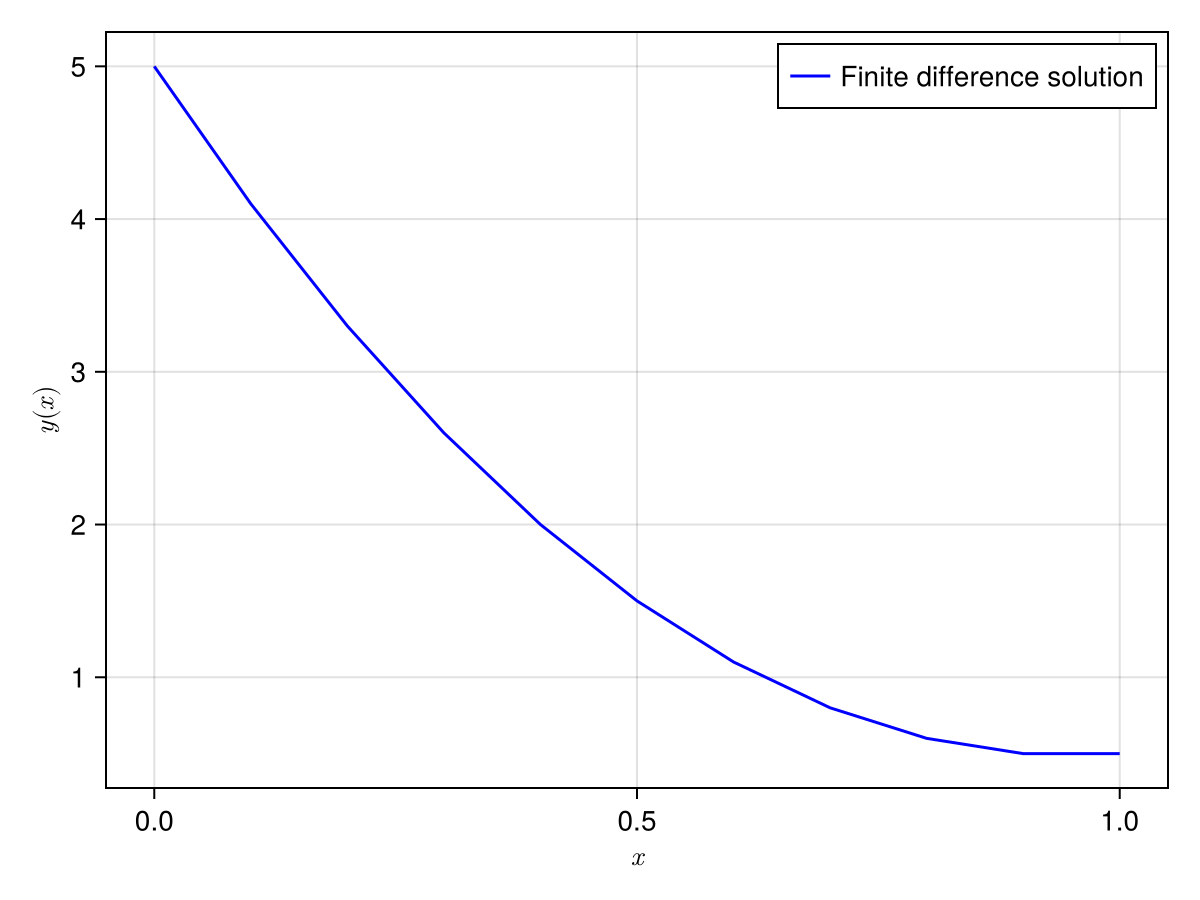

In [7]:
xplot=1:0.01:2
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y(x)")
lines!(ax,x,T,color=:blue,label="Finite difference solution")
axislegend(ax,position=:rt)
fig

In [8]:
T[end]

0.49999999999999944

For $k=0.1$, the value of $T(x=1)\approx 0.5$.  However, this value of $T(x=1)$ changes ( is dependendant on) with the ThermalConductivity, $k$.  To find out how $T(x=1)$ changes with $k$, we need to run many simulations with different values of  $k$.  We run the simulations with $k\in [0.1,1.0]$

In [9]:
ThermalCondVect=0.1:0.02:1.0

EndTemperature=similar(ThermalCondVect)

for i=1:length(ThermalCondVect)
    ThermalConductivity=ThermalCondVect[i]
    C[2:n-1].=1.0/ThermalConductivity
    prob=LinearProblem(A,C)
    #prob=LinearProblem(A_sparse,C)
    #y=LinearSolve.solve(prob,KrylovJL_GMRES())
    y=LinearSolve.solve(prob)
    EndTemperature[i]=y[end]
end

Let's plot our results to see how the predicted $T(x=1)$ changes with $k$. 

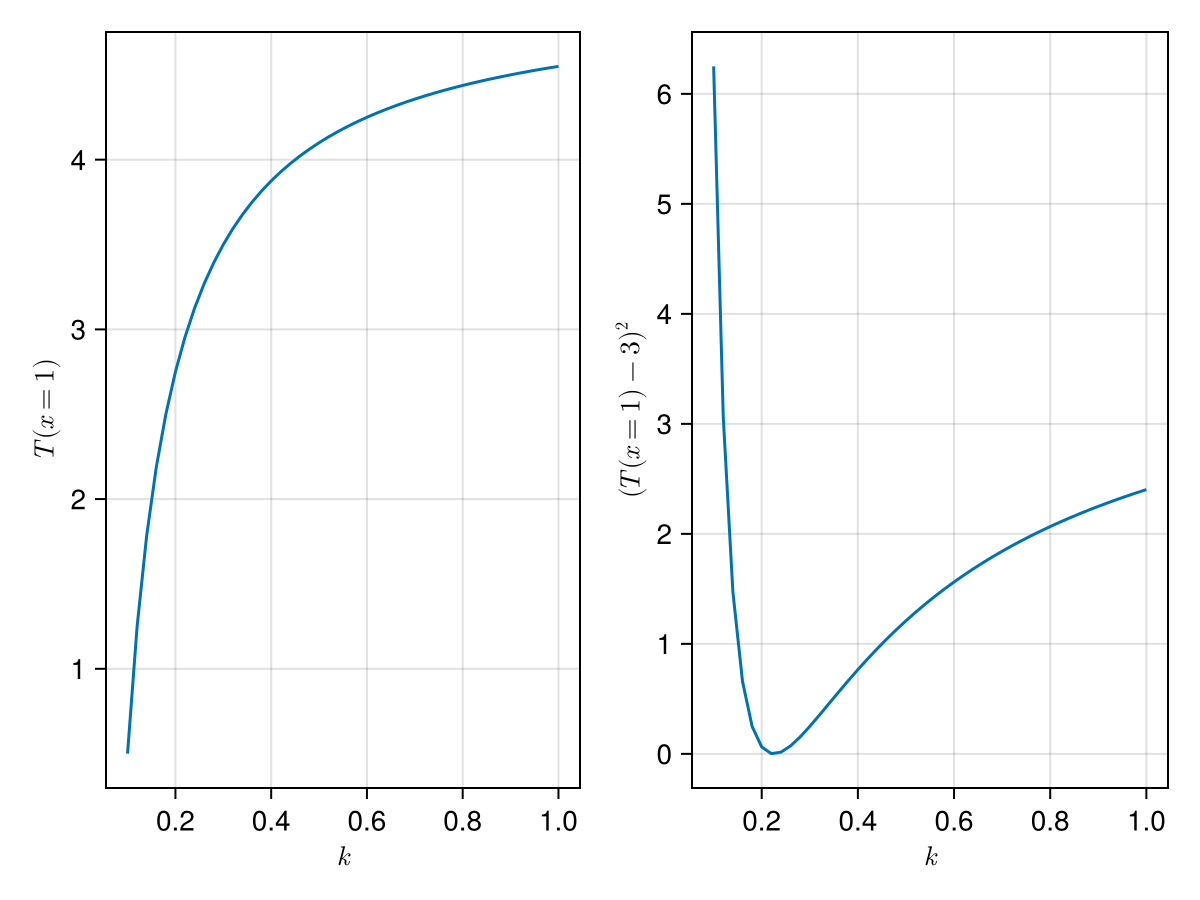

In [10]:
fig = Figure()
ax1 = Axis(fig[1, 1], xlabel = L"k", ylabel = L"T(x=1)")
lines!(ax1,ThermalCondVect, EndTemperature)

ax2 = Axis(fig[1, 2], xlabel = L"k", ylabel = L"(T(x=1)-3)^2")
lines!(ax2,ThermalCondVect, (EndTemperature.-3).^2)
save("../figures/05p04ParameterEstimationBVP0101.svg",fig)
fig

From the graph above, you see that the value of $k$ when $T(2)\approx 3$ is $k\approx 0.22$.

Now we will cast this as an optimization problem and try to solve for $k$ when $T(x=1)=3$

In [11]:
function loss(p,ydesired)

    C=ones(n)./p[1]
    C[1]=5.0
    C[n]=0.0
    prob=LinearProblem(A,C)
    y=LinearSolve.solve(prob)

    return sum((y[end]-ydesired[1]).^2)
end

loss (generic function with 1 method)

In [12]:
function callback(state, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Current loss after $(length(losses)) iterations: $(losses[end])")
    end
    return false
end

callback (generic function with 1 method)

In [13]:
using Optimization
using Optimisers
using OptimizationOptimisers
using ForwardDiff

losses = Float64[]
adtype = AutoForwardDiff()
optf = OptimizationFunction(loss, adtype)
optprob = OptimizationProblem(optf,[0.1],[3])
@time sol=Optimization.solve(optprob,Adam(0.01f0),maxiters=5000, callback=callback)

Current loss after 50 iterations: 0.017902182082700425
Current loss after 100 iterations: 3.0014221262495817e-5
Current loss after 150 iterations: 3.713679149612194e-7
Current loss after 200 iterations: 7.147555366852502e-10
Current loss after 250 iterations: 2.8078609599125373e-12
Current loss after 300 iterations: 1.7172790002297611e-13
Current loss after 350 iterations: 4.965430287228123e-16
Current loss after 400 iterations: 2.2488920620892987e-18
Current loss after 450 iterations: 1.464381826163917e-20
Current loss after 500 iterations: 1.2537875103075318e-22
Current loss after 550 iterations: 3.384410498624446e-27
Current loss after 600 iterations: 2.3003183996244704e-27
Current loss after 650 iterations: 1.262177448353619e-29
Current loss after 700 iterations: 1.9721522630525295e-31
Current loss after 750 iterations: 1.9721522630525295e-31
Current loss after 800 iterations: 1.9721522630525295e-31
Current loss after 850 iterations: 1.9721522630525295e-31
Current loss after 900 it

retcode: Default
u: 1-element Vector{Float64}:
 0.22499999999999995

In [14]:
# Evaluate the derivative at k=0.22....
df = ForwardDiff.derivative((p)->loss(p,[3.0]),0.225)

7.894919286223337e-15